In [9]:
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn

In [3]:
# This ensures all required packages are present in your 'moodmate' environment
!pip install --upgrade pip
!pip install numpy pandas matplotlib seaborn scikit-learn
print("✅ Environment setup complete! All libraries are installed in your active kernel.")

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 2.8 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 2.8 MB/s eta 0:00:00


ERROR: To modify pip, please run the following command:
C:\Users\nskum\anaconda3\python.exe -m pip install --upgrade pip


✅ Environment setup complete! All libraries are installed in your active kernel.


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn helper tools
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Set seeds for absolute reproducibility
np.random.seed(42)

# Generate a non-linear binary dataset (Moons dataset)
X_raw, y_raw = make_moons(n_samples=300, noise=0.25, random_state=42)

# Convert to a Pandas DataFrame for professional presentation
dataset_df = pd.DataFrame(X_raw, columns=['Feature_0', 'Feature_1'])
dataset_df['Target_Class'] = y_raw

print("✅ Step 1 Successful!")
print(f"Dataset generated with {dataset_df.shape[0]} rows and {dataset_df.shape[1]-1} input features.")
print("\nFirst 5 rows of our dataset:")
display(dataset_df.head())

✅ Step 1 Successful!
Dataset generated with 300 rows and 2 input features.

First 5 rows of our dataset:


,Feature_0,Feature_1,Target_Class
0,0.864396,-0.264509,1
1,2.451154,-0.117550,1
2,-0.350712,0.449211,1
3,0.741296,0.432919,0
4,1.188756,-0.518301,1


In [13]:
# 1. Feature Scaling using StandardScaler (makes Mean = 0, StdDev = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2. Split dataset into 80% Training (to teach the models) and 20% Testing (to grade them)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_raw, test_size=0.20, random_state=42, stratify=y_raw
)

print("✅ Step 2 Preprocessing Successful!")
print(f"Training vectors shape: {X_train.shape} (80% of data)")
print(f"Testing vectors shape:  {X_test.shape} (20% of data)")


✅ Step 2 Preprocessing Successful!
Training vectors shape: (240, 2) (80% of data)
Testing vectors shape:  (60, 2) (20% of data)


In [15]:
# Initialize Logistic Regression with L2 Regularization (C=1.0)
log_reg_model = LogisticRegression(C=1.0, max_iter=200, random_state=42)

# Perform 5-Fold Cross Validation on Training Data
# This splits the training data 5 times to check for stability
lr_cv_scores = cross_val_score(log_reg_model, X_train, y_train, cv=5, scoring='accuracy')

# Fit (Train) the model on the full training dataset
log_reg_model.fit(X_train, y_train)

print("✅ Model A (Logistic Regression) Trained Successfully!")
print(f"5-Fold CV Accuracies: {lr_cv_scores}")
print(f"Average Cross-Validation Accuracy: {lr_cv_scores.mean() * 100:.2f}%")


✅ Model A (Logistic Regression) Trained Successfully!
5-Fold CV Accuracies: [0.91666667 0.875      0.875      0.91666667 0.875     ]
Average Cross-Validation Accuracy: 89.17%


In [17]:
# Initialize a Random Forest ensemble (using 15 trees, max depth of 6)
random_forest_model = RandomForestClassifier(n_estimators=15, max_depth=6, random_state=42)

# Perform 5-Fold Cross Validation on Training Data
rf_cv_scores = cross_val_score(random_forest_model, X_train, y_train, cv=5, scoring='accuracy')

# Fit (Train) the model on the training dataset
random_forest_model.fit(X_train, y_train)

print("✅ Model B (Random Forest) Trained Successfully!")
print(f"5-Fold CV Accuracies: {rf_cv_scores}")
print(f"Average Cross-Validation Accuracy: {rf_cv_scores.mean() * 100:.2f}%")


✅ Model B (Random Forest) Trained Successfully!
5-Fold CV Accuracies: [0.9375     0.85416667 0.875      0.95833333 0.91666667]
Average Cross-Validation Accuracy: 90.83%


In [19]:
def evaluate_model(model, X_test, y_test):
    # Predict binary classes (0 or 1)
    predictions = model.predict(X_test)
    # Predict continuous probabilities (used for ROC-AUC)
    probabilities = model.predict_proba(X_test)[:, 1]
    
    # Calculate metrics
    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions)
    rec = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    auc = roc_auc_score(y_test, probabilities)
    
    return acc, prec, rec, f1, auc, predictions, probabilities

# Evaluate both models
acc_A, prec_A, rec_A, f1_A, auc_A, preds_A, probs_A = evaluate_model(log_reg_model, X_test, y_test)
acc_B, prec_B, rec_B, f1_B, auc_B, preds_B, probs_B = evaluate_model(random_forest_model, X_test, y_test)

# Display a comparison DataFrame
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC Score'],
    'Model A: Logistic Regression': [acc_A, prec_A, rec_A, f1_A, auc_A],
    'Model B: Random Forest': [acc_B, prec_B, rec_B, f1_B, auc_B]
}
metrics_df = pd.DataFrame(comparison_data)

print("📊 FINAL MODEL COMPARISON REPORT")
print("========================================")
display(metrics_df.round(4))


📊 FINAL MODEL COMPARISON REPORT


,Metric,Model A: Logistic Regression,Model B: Random Forest
0,Accuracy,0.8000,0.8833
1,Precision,0.7500,0.8485
2,Recall,0.9000,0.9333
3,F1-Score,0.8182,0.8889
4,ROC-AUC Score,0.9011,0.9383


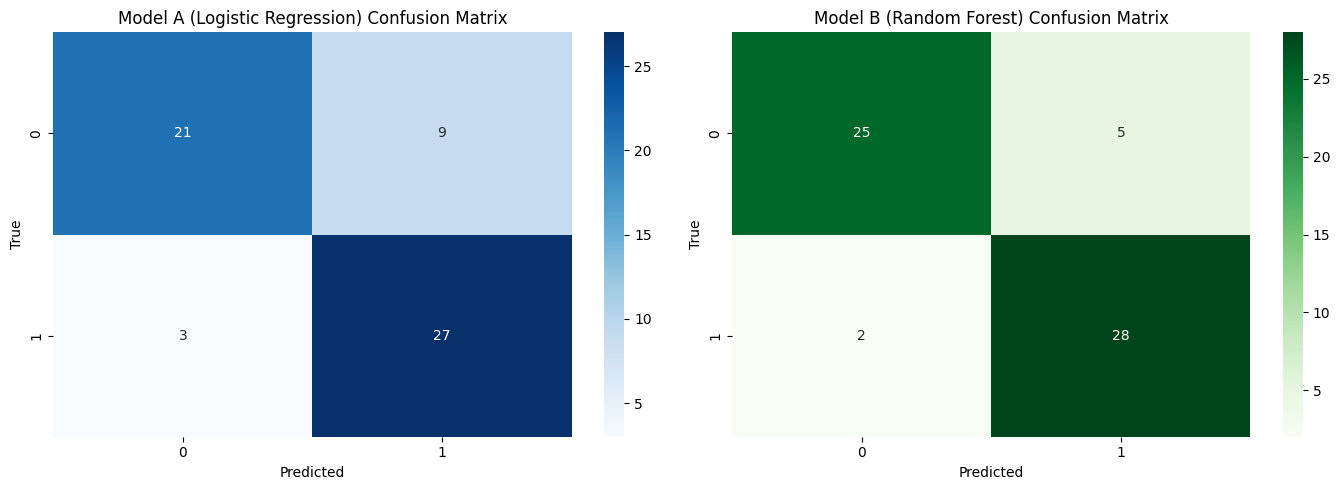

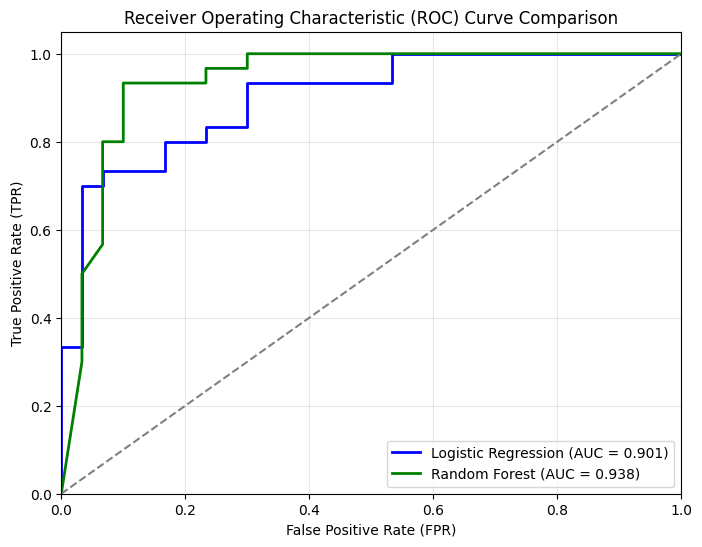

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Confusion Matrices side-by-side
cm_A = confusion_matrix(y_test, preds_A)
cm_B = confusion_matrix(y_test, preds_B)

sns.heatmap(cm_A, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Model A (Logistic Regression) Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_B, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("Model B (Random Forest) Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
plt.tight_layout()
plt.show()

# 2. Plot ROC-AUC Curves
plt.figure(figsize=(8, 6))
fpr_A, tpr_A, _ = roc_curve(y_test, probs_A)
fpr_B, tpr_B, _ = roc_curve(y_test, probs_B)

plt.plot(fpr_A, tpr_A, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_A:.3f})')
plt.plot(fpr_B, tpr_B, color='green', lw=2, label=f'Random Forest (AUC = {auc_B:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--') # diagonal baseline

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()
